[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1Wy5uvuJW8Lv6u2oA-reiQGiAm-jpYAfq#scrollTo=nw5uQnGcBeak)

# Mechanistic Interpretability Assignment

**Methods shown in this notebook:**
* Training a small MLP to solve a regression task (predicting the hidden weights applied to a set of binary numbers)

* Visualizing hidden layer activations averaged by input type (number of 1s)

* Performing neuron ablation (zeroing hidden neurons) to test their functional role

* Visualizing the effect of each individual neurons on the model’s output

* Inspecting both averaged activations and individual activations for specific inputs (not just averaged)

* Visualizing and comparing intermediate representations for fully connected layer 1 and hidden layer (fully connected layer 2).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

### Data Generation

#### Problem Statement

The neural network is to infer a set of secret weights applied to a set of binary inputs (1,0,...,0) of the same length. A synthetic training dataset will be generated based on this idea, but the secret weights do not change.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Config
input_dim = 8    #  Length of the binary input vector
hidden_dim = 8   #  Choose 8 hidden neurons, one for each input weight
n_samples = 2000 # Number of training examples
n_epoches = 200  # Number of epoches

# The model must figure out these secret weights.
secret_weights = torch.tensor([0.5, 2.0, -1.0, 3.5, -0.8, 1.5, 0.2, -2.5], dtype=torch.float32)

def generate_data(n_samples):
    # Generate random binary inputs (0 or 1)
    X = torch.randint(0, 2, (n_samples, input_dim), dtype=torch.float32)

    # Calculate the target Y = X . secret_weights + noise
    # The dot product selects and sums the active secret_weights
    Y = torch.matmul(X, secret_weights.unsqueeze(1))

    # Add a small amount of Gaussian noise to make it non-trivial
    noise = torch.randn(n_samples, 1) * 0.05
    Y += noise

    return X, Y

In [3]:
X_train, y_train = generate_data(n_samples)

# Make a small validation set
X_val, y_val = generate_data(int(n_samples * 0.2))

print(f"Dataset generated. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Secret Weights: {secret_weights}")

Dataset generated. X_train shape: torch.Size([2000, 8]), y_train shape: torch.Size([2000, 1])
Secret Weights: tensor([ 0.5000,  2.0000, -1.0000,  3.5000, -0.8000,  1.5000,  0.2000, -2.5000])


### Build a Tiny MLP (multilayer perceptron) Model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# Model
class WeightingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # Maps the 8 inputs to the 8 hidden dimensions
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Maps the 8 hidden activations to the single output (regression)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # Return hidden activation for interpretation

model = WeightingMLP(input_dim=input_dim, hidden_dim=hidden_dim)
print("\nModel Architecture:\n", model)


Model Architecture:
 WeightingMLP(
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [13]:
# Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
criterion = nn.MSELoss() # Mean Squared Error for regression

losses = []
for epoch in range(n_epoches):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
      print(f'Epoch {epoch+1}/{n_epoches}, Loss: {loss.item():.4f}')

print(f"\nFinal training loss: {losses[-1]:.3f}")

# Evaluation and interpretation
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    # Calculate Mean Absolute Error (MAE) for evaluation
    mae = torch.abs(preds - y_val).mean().item()

print(f"Validation MAE: {mae:.3f}")

Epoch 50/200, Loss: 0.2064
Epoch 100/200, Loss: 0.0162
Epoch 150/200, Loss: 0.0069
Epoch 200/200, Loss: 0.0047

Final training loss: 0.005
Validation MAE: 0.048


### Weight Matrices

In [14]:
# Extract the weight matrix for the first layer (W_1) and second layer (W_2)
w1 = model.fc1.weight.data
w2 = model.fc2.weight.data

print("W1 shape:", w1.shape)
print("W2 shape:", w2.shape)

W1 shape: torch.Size([8, 8])
W2 shape: torch.Size([1, 8])


In [15]:
w1, w2

(tensor([[ 0.3596,  0.8872, -0.0257,  0.8434,  0.0164,  0.5340,  0.2966, -0.0482],
         [ 0.5786, -0.2008,  0.9355, -0.8061,  0.9384,  0.1487,  0.5770,  0.9324],
         [ 0.5565,  0.4362,  0.0532,  0.7355,  0.2882,  0.5258,  0.4927, -0.6884],
         [ 0.1838,  0.3553,  0.0034,  0.9346, -0.0698,  0.4947,  0.2092, -0.1854],
         [ 0.1232,  0.4210,  0.0806,  0.8014,  0.0927,  0.3082,  0.1477, -0.7275],
         [ 0.5825,  0.7740, -0.0989,  0.5402,  0.0339,  0.7863, -0.0023, -0.3388],
         [ 0.0770,  0.0146, -0.3469, -0.5220, -0.2240,  0.0072, -0.4458, -0.3166],
         [-0.2679, -0.3834,  0.0850, -0.2155,  0.0450, -0.1688, -0.0346,  1.0838]]),
 tensor([[ 0.6122, -1.1002,  0.7717,  0.8710,  0.6129,  0.3762, -0.1306, -0.2567]]))

Weight Matrix approximations:

In [16]:
learned_weights_approx = (w1 * w2.T).diag()

print("\nSecret Weights:             ", [f"{w:.2f}" for w in secret_weights.tolist()])
print("Model's Learned Weights (Approx.):", [f"{w:.2f}" for w in learned_weights_approx.tolist()])


Secret Weights:              ['0.50', '2.00', '-1.00', '3.50', '-0.80', '1.50', '0.20', '-2.50']
Model's Learned Weights (Approx.): ['0.22', '0.22', '0.04', '0.81', '0.06', '0.30', '0.06', '-0.28']


Fully Connected Layer 2 Weights

In [21]:
# Extract weight tensors
w1 = model.fc1.weight.data
w2 = model.fc2.weight.data.squeeze() # 1x8 becomes 8

# The learned weights are primarily found in the w2 vector (from fc2 layer weights)
learned_weights = w2

print(f"\nSecret Weights: {[f'{w:.2f}' for w in secret_weights.tolist()]}")
print(f"Learned Weights (w2): {[f'{w:.2f}' for w in learned_weights.tolist()]}")


Secret Weights: ['0.50', '2.00', '-1.00', '3.50', '-0.80', '1.50', '0.20', '-2.50']
Learned Weights (w2): ['0.61', '-1.10', '0.77', '0.87', '0.61', '0.38', '-0.13', '-0.26']


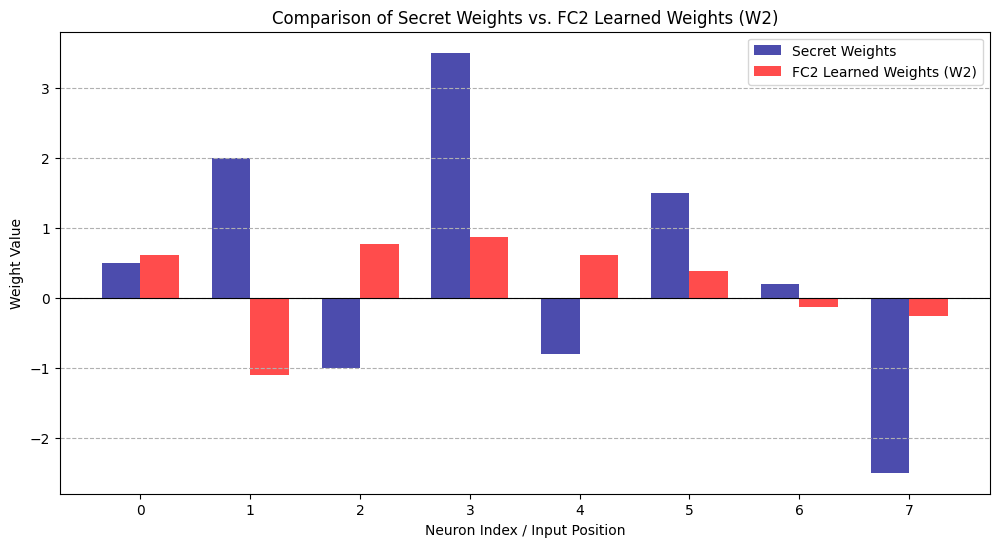

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Actual Secret Weights from the "Weighting Puzzle" task
secret_weights = torch.tensor([0.5, 2.0, -1.0, 3.5, -0.8, 1.5, 0.2, -2.5], dtype=torch.float32)

# Convert to NumPy for plotting
secret_np = secret_weights.numpy()
w2_np = w2.numpy()
indices = np.arange(len(secret_np))
bar_width = 0.35

# Plot
plt.figure(figsize=(12, 6))

# Plot secret weights
plt.bar(indices - bar_width/2, secret_np, bar_width, label='Secret Weights', color='darkblue', alpha=0.7)

# Plot learned w2 weights
plt.bar(indices + bar_width/2, w2_np, bar_width, label='FC2 Learned Weights (W2)', color='red', alpha=0.7)

# Labels
plt.xlabel('Neuron Index / Input Position')
plt.ylabel('Weight Value')
plt.title('Comparison of Secret Weights vs. FC2 Learned Weights (W2)')
plt.xticks(indices, labels=[str(i) for i in indices]) # Ensure indices 0-7 are labeled
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.grid(axis='y', linestyle='--')

Fully Connected Layer 1 (FC1)  Weights Heatmap

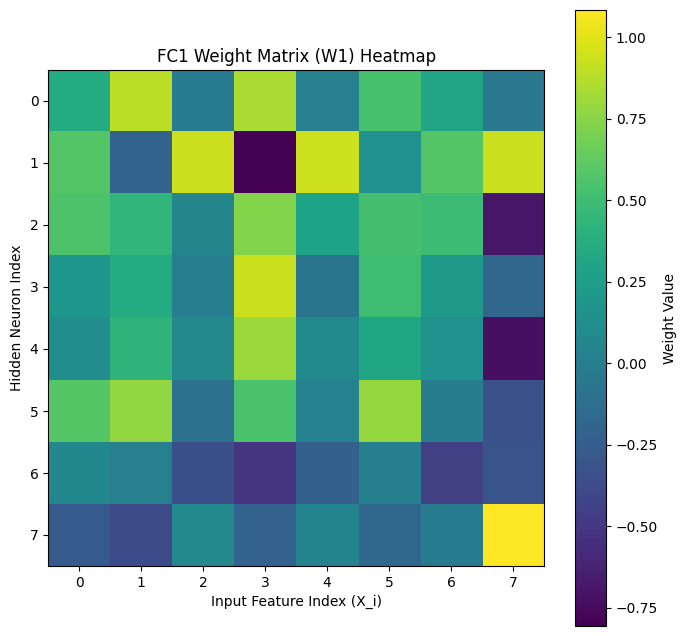

In [20]:
plt.figure(figsize=(8, 8))

# Create the heatmap
plt.imshow(w1.numpy(), cmap='viridis', aspect='equal')

# Labeling
plt.xlabel("Input Feature Index (X_i)")
plt.ylabel("Hidden Neuron Index")
plt.title("FC1 Weight Matrix (W1) Heatmap")
plt.colorbar(label='Weight Value')

# Set ticks for clarity (0 to 7)
ticks = np.arange(8)
plt.xticks(ticks)
plt.yticks(ticks)

plt.show()

### Print Activations of a sample input (random 8 binary numbers)

In [19]:
with torch.no_grad():
    sample_input = torch.tensor([[1, 0, 1, 0, 1, 1, 0, 0]], dtype=torch.float32)
    logits, hidden = model(sample_input)

print(f"Sample Input: {sample_input}")
print(f"Hidden Layer Activations: {hidden}")
print(f"Output Logits: {logits}")
rounded = round(logits.item())
print(f"Rounded Prediction: {rounded}")

Sample Input: tensor([[1., 0., 1., 0., 1., 1., 0., 0.]])
Hidden Layer Activations: tensor([[0.9424, 3.5468, 1.7818, 0.8149, 1.0188, 1.5178, 0.0000, 0.0000]])
Output Logits: tensor([[0.2251]])
Rounded Prediction: 0


### Plot hidden activations across different numbers of 1s as input

In [14]:
n_classes = len(secret_weights) + 1
total_neurons = hidden_dim + 1 # hidden neurons + output neuron

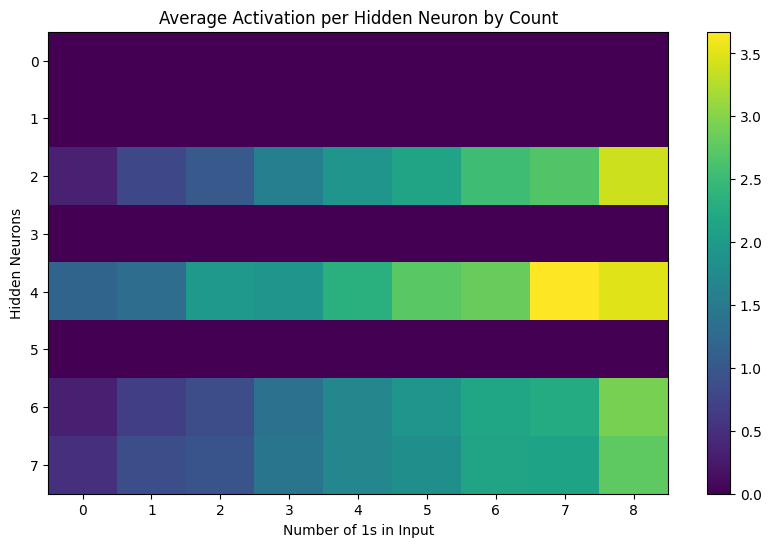

In [15]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# The possible number of 1s ranges from 0 to 8 (8+1=9).
n_groups = 9

# Calculate the actual count of '1's for every validation input, which is a tensor of integers.
input_counts = X_val.sum(dim=1).long()

# Initialize the array to store average activations.
avg_activations = torch.zeros((n_groups, hidden_dim))

# Iterate from count c = 0 up to 8.
for c in range(n_groups):
    # Select all validation inputs that have exactly 'c' number of 1s.
    class_inputs = X_val[input_counts == c]

    if class_inputs.shape[0] > 0:
        # Run forward pass to get hidden activations (h)
        _, h = model(class_inputs)
        # Store the mean activation across all samples with this count 'c'
        avg_activations[c] = h.mean(dim=0)

plt.figure(figsize=(10, 6))

# Transpose the array to have Neurons on the Y-axis and Counts on the X-axis
activations_np = avg_activations.T.detach().numpy()

plt.imshow(activations_np, aspect='auto', cmap='viridis')
plt.xlabel("Number of 1s in Input")
plt.ylabel("Hidden Neurons")
plt.title("Average Activation per Hidden Neuron by Count")
plt.colorbar()
plt.xticks(np.arange(n_groups), labels=range(n_groups)) # Ensure X-axis labels are correct
plt.show()

#### **What does this plot show?**
The plot shows the average activate per hidden neuron by count (x axis is the number of 1s in the input, y axis shows hidden neurons)

##### *Neuron Specialization*
Hidden neuron 4 appears to have the brightest across all counts compared to other neurons.

##### *Monotonic Trends*
The activating neurons 2,4,6,7 show a gradual increase in activation with count. They may be learning a linear or thresholded count pattern.

It's an example of linearly increasing features (or linear probability).

##### *Redundant or Silent Units*
Neurons 0,1,3,5 appear to be quite consistently dark: either supressed or unused.

##### *Activation Superposition*
Some neurons activate across a range of counts, possibly blending multiple input features.

### Neuron Ablation (single neuron)

This is for the hidden layer

In [18]:
# Ablation Config
test_input = torch.tensor([[1, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.float32)

# Calculate the True Target (Weighted Sum) for this specific input
# This replaces the simple "True count" from the original task
true_target = torch.sum(test_input * secret_weights).item()

# Baseline prediction
model.eval()
with torch.no_grad():
    baseline_output, _ = model(test_input)
    baseline_pred = baseline_output.item()

# Manual Ablation Forward Pass

for neuron_to_zero in range(hidden_dim):
  # Calculate pre-output hidden activations
  with torch.no_grad():
      h = F.relu(model.fc1(test_input))

      # 2. Ablate the selected neuron
      h[:, neuron_to_zero] = 0

      # 3. Calculate modified output
      modified_output = model.fc2(h)
      modified_pred = modified_output.item()

  # Results
  print(f"True Target (Weighted Sum): {true_target:.2f}")
  print(f"Prediction (Normal Baseline): {baseline_pred:.2f}")

  delta = modified_pred - baseline_pred

  print(f"\n✅ Neuron {neuron_to_zero} Ablated:")
  print(f"   Modified Prediction: {modified_pred:.2f}")
  print("---------------------------------------------")

True Target (Weighted Sum): 3.20
Prediction (Normal Baseline): 3.20

✅ Neuron 0 Ablated:
   Modified Prediction: 3.20
---------------------------------------------
True Target (Weighted Sum): 3.20
Prediction (Normal Baseline): 3.20

✅ Neuron 1 Ablated:
   Modified Prediction: 3.20
---------------------------------------------
True Target (Weighted Sum): 3.20
Prediction (Normal Baseline): 3.20

✅ Neuron 2 Ablated:
   Modified Prediction: 1.46
---------------------------------------------
True Target (Weighted Sum): 3.20
Prediction (Normal Baseline): 3.20

✅ Neuron 3 Ablated:
   Modified Prediction: 3.20
---------------------------------------------
True Target (Weighted Sum): 3.20
Prediction (Normal Baseline): 3.20

✅ Neuron 4 Ablated:
   Modified Prediction: 5.48
---------------------------------------------
True Target (Weighted Sum): 3.20
Prediction (Normal Baseline): 3.20

✅ Neuron 5 Ablated:
   Modified Prediction: 3.20
---------------------------------------------
True Target (Wei

#### **What does the ablation tell us?**

If the prediction changes significantly after zeroing out a neuron, that neuron likely plays an important functional role in the model’s decision!

The for-loop is to determine the effect of zerioing out each neuron. Neurons 0,1,3,5 appear to have identical modification to the prediction once removed. Neuron 4 is most important (largest modification if absent). All other neurons appear to be less significant to the output.

### Neuron Ablation (sweep of neurons)

💰 True Target (Weighted Sum): 3.20, Baseline prediction: 3.20


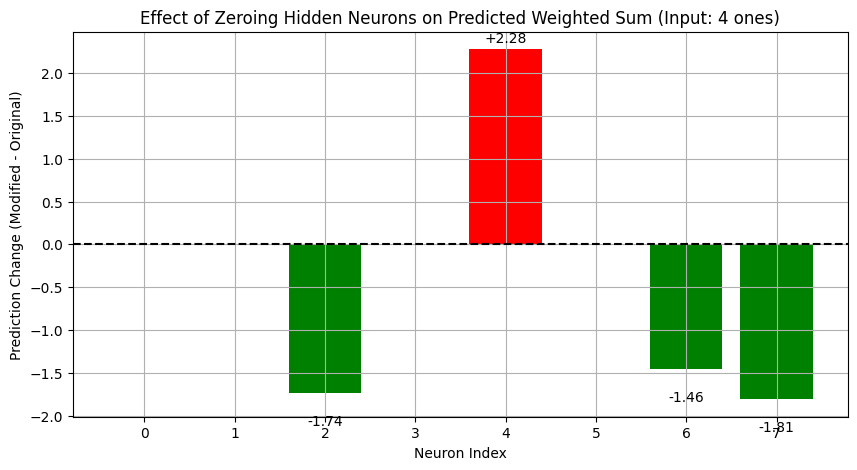

Neuron 2 → Prediction decreased by 1.74
Neuron 4 → Prediction increased by 2.28
Neuron 6 → Prediction decreased by 1.46
Neuron 7 → Prediction decreased by 1.81


In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Calculate the count to demonstrate the sparsity of the input
count_of_ones = int(test_input.sum().item())

# Baseline prediction
model.eval()
with torch.no_grad():
    baseline_output, _ = model(test_input)
    baseline_pred = baseline_output.item()

# Adapted print statement
print(f"💰 True Target (Weighted Sum): {true_target:.2f}, Baseline prediction: {baseline_pred:.2f}")

# get signed change in scalar prediction
neuron_indices = list(range(model.fc1.out_features))
signed_deltas = []

for i in neuron_indices:
    with torch.no_grad():
        h = F.relu(model.fc1(test_input))
        h[:, i] = 0  # zero out neuron i
        mod_output = model.fc2(h)
        mod_pred = mod_output.item()
        signed_deltas.append(mod_pred - baseline_pred)

# --- Plotting signed prediction change per neuron ---
plt.figure(figsize=(10, 5))
colors = ['green' if d < 0 else 'red' if d > 0 else 'gray' for d in signed_deltas]

plt.bar(neuron_indices, signed_deltas, color=colors)
plt.axhline(0, color='black', linestyle='--')
plt.xticks(neuron_indices)
plt.xlabel("Neuron Index")
plt.ylabel("Prediction Change (Modified - Original)")

# Plot Title
plt.title(f"Effect of Zeroing Hidden Neurons on Predicted Weighted Sum (Input: {count_of_ones} ones)")
plt.grid(True)

# Annotation
for i, d in enumerate(signed_deltas):
    if abs(d) > 1e-3:
        plt.text(i, d + (0.05 if d > 0 else -0.25), f"{d:+.2f}",
                 ha='center', va='bottom' if d > 0 else 'top')

plt.show()

# Summary
for i, d in enumerate(signed_deltas):
    if abs(d) > 1e-3:
        direction = "increased" if d > 0 else "decreased"
        print(f"Neuron {i} → Prediction {direction} by {abs(d):.2f}")

#### **What does the sweep of neuron ablations tell us?**

As confirmed, neuron 4 has the biggest impact.

For neurons 0, 1,3,and 5, there seem to be little change after zeroing them.